# Unidade VI — Análise de Grupos

## Agrupamento hierárquico e DBSCAN

**Carga estimada:** 3 horas  
**Pré-requisitos:** distância, padronização e fundamentos de análise de grupos.

> **Pergunta norteadora:** como encontrar grupos quando queremos examinar diferentes níveis de granularidade ou quando os grupos não se parecem com regiões aproximadamente esféricas?

Estudaremos métodos hierárquicos, que constroem uma árvore de agrupamentos, e o DBSCAN, que conecta regiões densas e pode marcar objetos como ruído.

## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- distinguir estratégias aglomerativas e divisivas;
- explicar as ligações simples, completa, média e Ward;
- ler fusões, alturas e cortes em um dendrograma;
- explicar vizinhança, ponto central, borda e ruído no DBSCAN;
- analisar os efeitos de `eps` e `min_samples`;
- comparar k-means, agrupamento hierárquico e DBSCAN.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Circle
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.datasets import make_moons
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

## 1. Por que construir uma hierarquia?

Uma partição mostra apenas um nível de detalhe. Uma hierarquia permite observar grandes segmentos e, dentro deles, subgrupos. Ela pode representar uma estrutura substantiva ou funcionar apenas como instrumento de resumo e exploração.

- **Aglomerativa (*bottom-up*):** começa com um grupo por objeto e funde os dois grupos mais próximos a cada etapa.
- **Divisiva (*top-down*):** começa com todos os objetos juntos e divide grupos sucessivamente.

Trabalharemos com a estratégia aglomerativa. Uma fusão não é desfeita depois; por isso, distância, escala e ligação importam desde o início.

,x,y
A,0.0,0.0
B,0.3,0.2
C,0.2,0.8
D,2.5,2.2
E,2.9,2.4
F,5.2,0.2
G,5.6,0.5
H,5.3,1.0


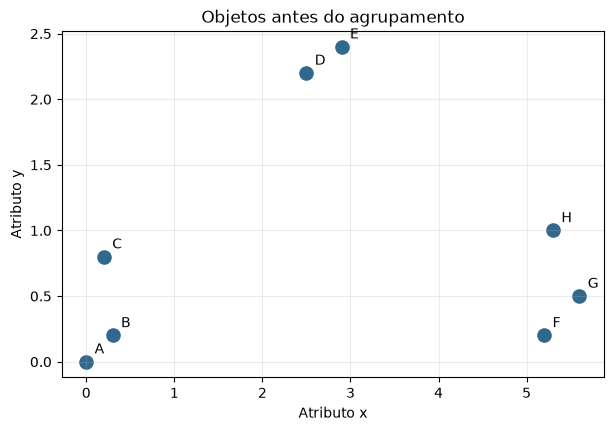

In [2]:
nomes = np.array(list("ABCDEFGH"))
X_h = np.array([
    [0.0, 0.0], [0.3, 0.2], [0.2, 0.8],
    [2.5, 2.2], [2.9, 2.4],
    [5.2, 0.2], [5.6, 0.5], [5.3, 1.0],
])
dados_h = pd.DataFrame(X_h, columns=["x", "y"], index=nomes)
display(dados_h)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(X_h[:, 0], X_h[:, 1], s=90, color="#31688e")
for nome, (x, y) in zip(nomes, X_h):
    ax.annotate(nome, (x, y), xytext=(6, 6), textcoords="offset points")
ax.set(title="Objetos antes do agrupamento", xlabel="Atributo x", ylabel="Atributo y")
ax.grid(alpha=0.25)
plt.show()

## 2. O que significa distância entre grupos?

O **critério de ligação** transforma as várias distâncias entre pares de pontos em uma distância entre grupos.

| Ligação | Definição | Tendência e atenção |
|---|---|---|
| simples | menor distância entre um ponto de cada grupo | encontra conexões locais; pode criar encadeamento |
| completa | maior distância entre um ponto de cada grupo | favorece grupos compactos; reage a pontos extremos |
| média | média das distâncias entre todos os pares | compromisso entre simples e completa |
| Ward | menor aumento da SSE pela fusão | favorece compactação; requer atributos numéricos e distância Euclidiana |

$$d_{simples}(C_i,C_j)=\min_{x\in C_i,y\in C_j}d(x,y),$$

$$d_{completa}(C_i,C_j)=\max_{x\in C_i,y\in C_j}d(x,y),$$

$$d_{média}(C_i,C_j)=\frac{1}{|C_i||C_j|}\sum_{x\in C_i}\sum_{y\in C_j}d(x,y).$$

Nenhuma ligação é universalmente melhor: cada uma operacionaliza uma ideia diferente de grupo.

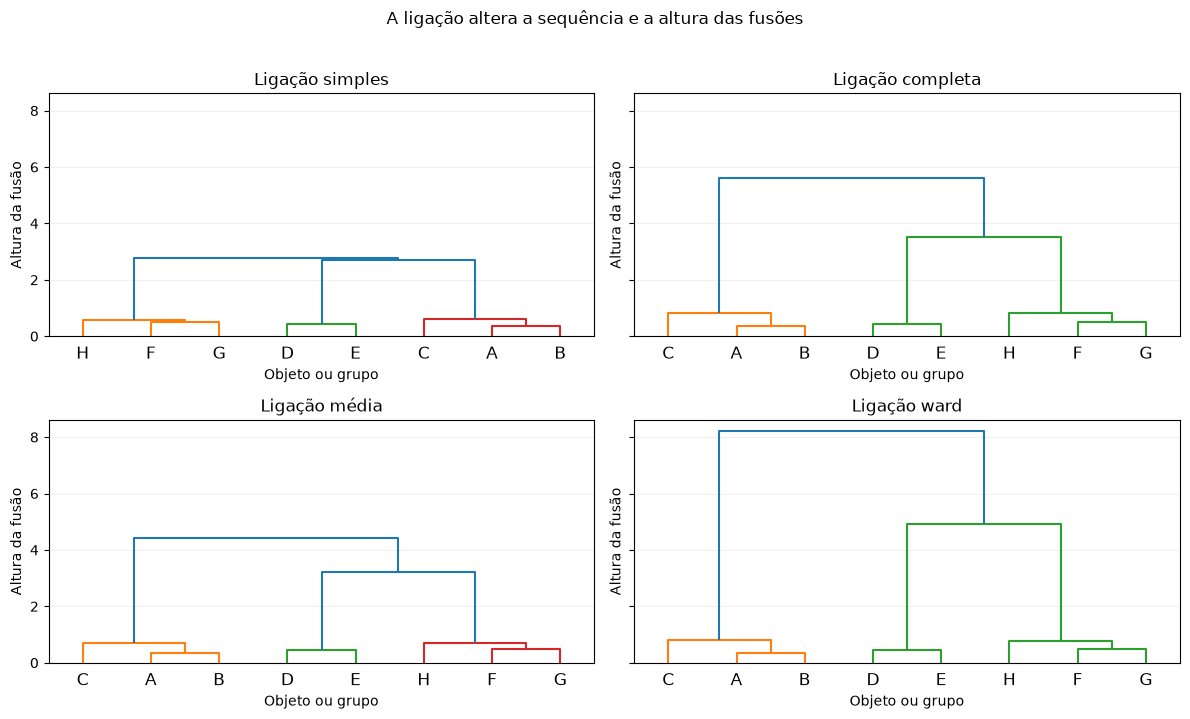

In [3]:
metodos = {"Simples": "single", "Completa": "complete", "Média": "average", "Ward": "ward"}
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
for ax, (titulo, metodo) in zip(axes.ravel(), metodos.items()):
    Z = linkage(X_h, method=metodo, metric="euclidean")
    dendrogram(Z, labels=nomes.tolist(), ax=ax, color_threshold=None)
    ax.set(title=f"Ligação {titulo.lower()}", xlabel="Objeto ou grupo", ylabel="Altura da fusão")
    ax.grid(axis="y", alpha=0.2)
fig.suptitle("A ligação altera a sequência e a altura das fusões", y=1.02)
fig.tight_layout()
plt.show()

## 3. Como ler um dendrograma

Leia o gráfico de baixo para cima:

1. as folhas são os objetos; sua ordem horizontal serve apenas para desenhar a árvore;
2. cada junção horizontal registra uma fusão;
3. a altura é o valor do critério na fusão — não é o tamanho do grupo;
4. um corte horizontal define uma partição: cada ramo interceptado corresponde a um grupo.

Um grande intervalo vertical pode sugerir um corte, mas não prova que o número de grupos seja útil. A decisão exige estabilidade, interpretação e finalidade.

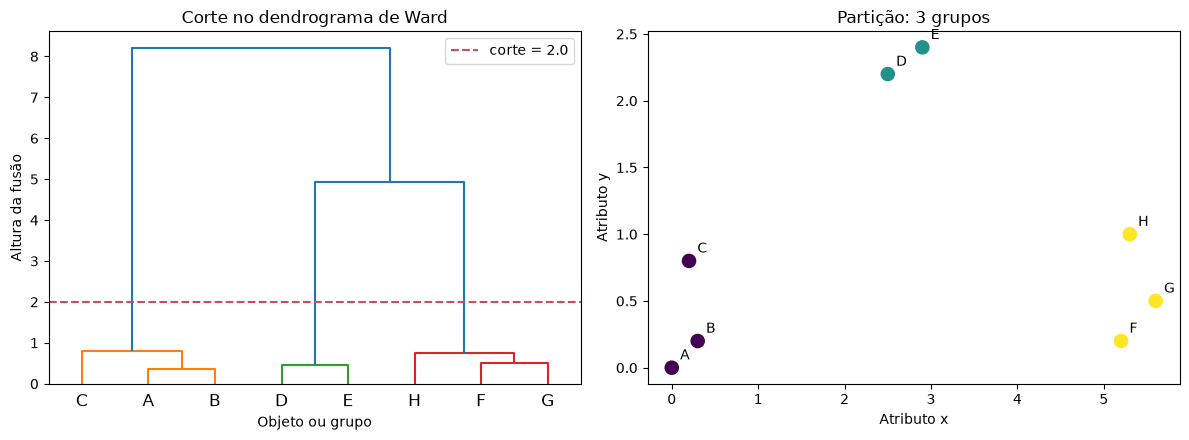

,objeto,grupo_no_corte
0,A,1
1,B,1
2,C,1
3,D,2
4,E,2
5,F,3
6,G,3
7,H,3


In [4]:
Z_ward = linkage(X_h, method="ward")
altura_corte = 2.0
rotulos_corte = fcluster(Z_ward, t=altura_corte, criterion="distance")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
dendrogram(Z_ward, labels=nomes.tolist(), ax=axes[0], color_threshold=altura_corte)
axes[0].axhline(altura_corte, color="#d1495b", linestyle="--", label=f"corte = {altura_corte}")
axes[0].set(title="Corte no dendrograma de Ward", xlabel="Objeto ou grupo", ylabel="Altura da fusão")
axes[0].legend()
axes[1].scatter(X_h[:, 0], X_h[:, 1], c=rotulos_corte, cmap="viridis", s=90)
for nome, (x, y) in zip(nomes, X_h):
    axes[1].annotate(nome, (x, y), xytext=(6, 6), textcoords="offset points")
axes[1].set(title=f"Partição: {len(np.unique(rotulos_corte))} grupos", xlabel="Atributo x", ylabel="Atributo y")
fig.tight_layout()
plt.show()
display(pd.DataFrame({"objeto": nomes, "grupo_no_corte": rotulos_corte}))

### Por que Ward se relaciona ao k-means?

Ward escolhe a fusão com o menor aumento da soma dos quadrados dentro dos grupos. Para tamanhos $n_i,n_j$ e médias $\boldsymbol{m}_i,\boldsymbol{m}_j$:

$$\Delta SSE(C_i,C_j)=\frac{n_i n_j}{n_i+n_j}\lVert\boldsymbol{m}_i-\boldsymbol{m}_j\rVert^2.$$

Assim como o k-means, Ward favorece grupos compactos. Ward preserva uma sequência de partições aninhadas; o k-means procura diretamente uma partição com $k$ grupos. Padronização continua necessária quando as escalas são incomparáveis.

## 4. DBSCAN: grupos como regiões densamente conectadas

O DBSCAN não procura centroides e não exige informar o número de grupos. Ele usa:

- `eps` ($\varepsilon$): raio que define a vizinhança;
- `min_samples`: mínimo de objetos na vizinhança, contando o próprio objeto no scikit-learn, para que ele seja central.

$$N_\varepsilon(p)=\{q\in D:d(p,q)\leq\varepsilon\}.$$

| Tipo | Condição | Papel |
|---|---|---|
| central (*core*) | $|N_\varepsilon(p)|\geq min\_samples$ | expande a região densa |
| borda | não é central, mas está na vizinhança de um central | pertence ao grupo, porém não o expande |
| ruído | não é central nem vizinho de um central | recebe rótulo `-1` |

Ruído é relativo aos parâmetros, à métrica e à representação; não significa automaticamente erro ou irrelevância.

,objeto,x,y,grupo,tipo
0,P,0.00,0.00,0,central
1,Q,0.25,0.05,0,central
2,R,-0.20,0.10,0,central
3,S,0.05,0.30,0,borda
4,T,-0.15,-0.25,0,central
5,U,0.35,-0.20,0,central
6,V,0.80,0.05,0,borda
7,W,2.00,1.50,-1,ruído


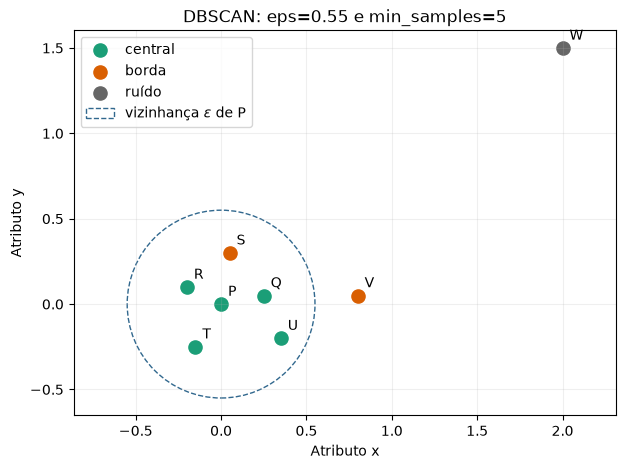

In [5]:
X_tipo = np.array([
    [0.00, 0.00], [0.25, 0.05], [-0.20, 0.10], [0.05, 0.30],
    [-0.15, -0.25], [0.35, -0.20], [0.80, 0.05], [2.00, 1.50],
])
eps_tipo, min_samples_tipo = 0.55, 5
modelo_tipo = DBSCAN(eps=eps_tipo, min_samples=min_samples_tipo).fit(X_tipo)
centrais = np.zeros(len(X_tipo), dtype=bool)
centrais[modelo_tipo.core_sample_indices_] = True
tipos = np.where(centrais, "central", np.where(modelo_tipo.labels_ == -1, "ruído", "borda"))
tabela_tipos = pd.DataFrame({"objeto": list("PQRSTUVW"), "x": X_tipo[:, 0], "y": X_tipo[:, 1], "grupo": modelo_tipo.labels_, "tipo": tipos})
display(tabela_tipos)

cores = {"central": "#1b9e77", "borda": "#d95f02", "ruído": "#666666"}
fig, ax = plt.subplots(figsize=(7, 5))
for tipo in ["central", "borda", "ruído"]:
    mask = tipos == tipo
    ax.scatter(X_tipo[mask, 0], X_tipo[mask, 1], s=90, color=cores[tipo], label=tipo)
for nome, (x, y) in zip(tabela_tipos["objeto"], X_tipo):
    ax.annotate(nome, (x, y), xytext=(5, 6), textcoords="offset points")
ax.add_patch(Circle(X_tipo[0], eps_tipo, fill=False, linestyle="--", color="#31688e", label=r"vizinhança $\varepsilon$ de P"))
ax.set(title=f"DBSCAN: eps={eps_tipo} e min_samples={min_samples_tipo}", xlabel="Atributo x", ylabel="Atributo y")
ax.legend()
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.2)
plt.show()

## 5. Como escolher `eps` e `min_samples`

`eps` pequeno fragmenta regiões e aumenta o ruído; grande pode unir regiões distintas. `min_samples` maior exige vizinhanças mais povoadas. Um único par pode falhar quando os grupos têm densidades muito diferentes.

No gráfico da distância ao $k$-ésimo vizinho, usamos $k=min\_samples$, ordenamos essas distâncias e procuramos uma mudança de inclinação. O valor é apenas um candidato: escala, dimensão e contexto continuam relevantes.

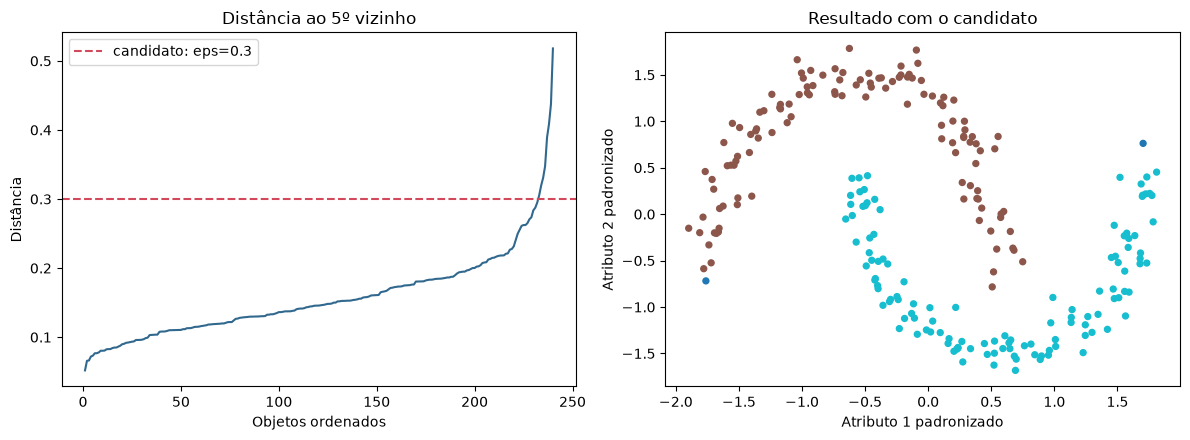

In [6]:
X_luas, y_luas = make_moons(n_samples=240, noise=0.07, random_state=RANDOM_STATE)
X_luas = StandardScaler().fit_transform(X_luas)
min_samples, eps_candidato = 5, 0.30
distancias, _ = NearestNeighbors(n_neighbors=min_samples).fit(X_luas).kneighbors(X_luas)
k_distancias = np.sort(distancias[:, -1])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(np.arange(1, len(k_distancias) + 1), k_distancias, color="#31688e")
axes[0].axhline(eps_candidato, color="#d1495b", linestyle="--", label=f"candidato: eps={eps_candidato}")
axes[0].set(title=f"Distância ao {min_samples}º vizinho", xlabel="Objetos ordenados", ylabel="Distância")
axes[0].legend()
labels_db = DBSCAN(eps=eps_candidato, min_samples=min_samples).fit_predict(X_luas)
axes[1].scatter(X_luas[:, 0], X_luas[:, 1], c=labels_db, cmap="tab10", s=18)
axes[1].set(title="Resultado com o candidato", xlabel="Atributo 1 padronizado", ylabel="Atributo 2 padronizado")
fig.tight_layout()
plt.show()

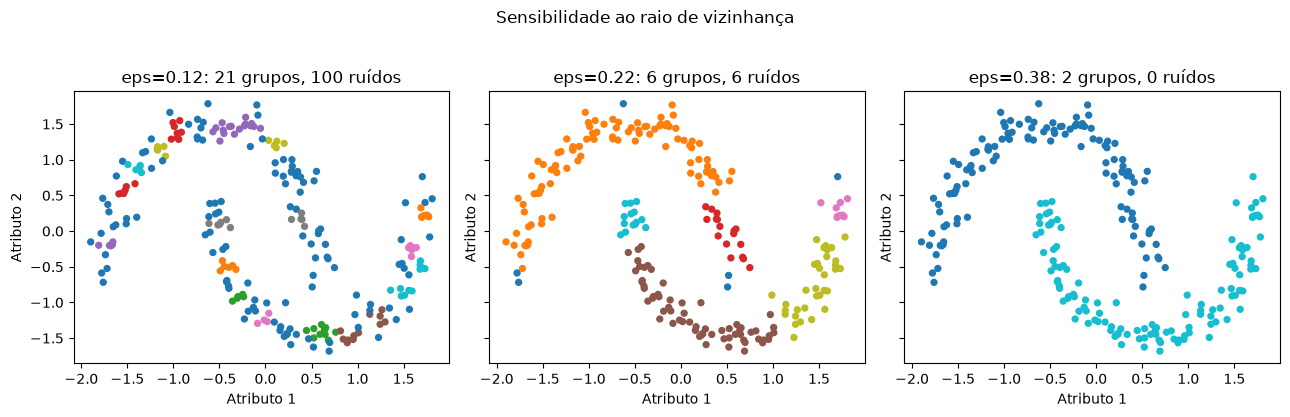

,eps,grupos,objetos_ruído
0,0.12,21,100
1,0.22,6,6
2,0.38,2,0


In [7]:
valores_eps = [0.12, 0.22, 0.38]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
resumo_eps = []
for ax, eps in zip(axes, valores_eps):
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_luas)
    n_grupos = len(set(labels) - {-1})
    n_ruido = int(np.sum(labels == -1))
    resumo_eps.append({"eps": eps, "grupos": n_grupos, "objetos_ruído": n_ruido})
    ax.scatter(X_luas[:, 0], X_luas[:, 1], c=labels, cmap="tab10", s=18)
    ax.set(title=f"eps={eps}: {n_grupos} grupos, {n_ruido} ruídos", xlabel="Atributo 1", ylabel="Atributo 2")
fig.suptitle("Sensibilidade ao raio de vizinhança", y=1.03)
fig.tight_layout()
plt.show()
display(pd.DataFrame(resumo_eps))

## 6. Mesmos dados, diferentes ideias de grupo

A representação e a escala serão idênticas. Para k-means e Ward, informamos dois grupos; para DBSCAN, usamos os parâmetros investigados. A contagem de grupos e ruídos descreve a saída, mas não mede sozinha sua qualidade.

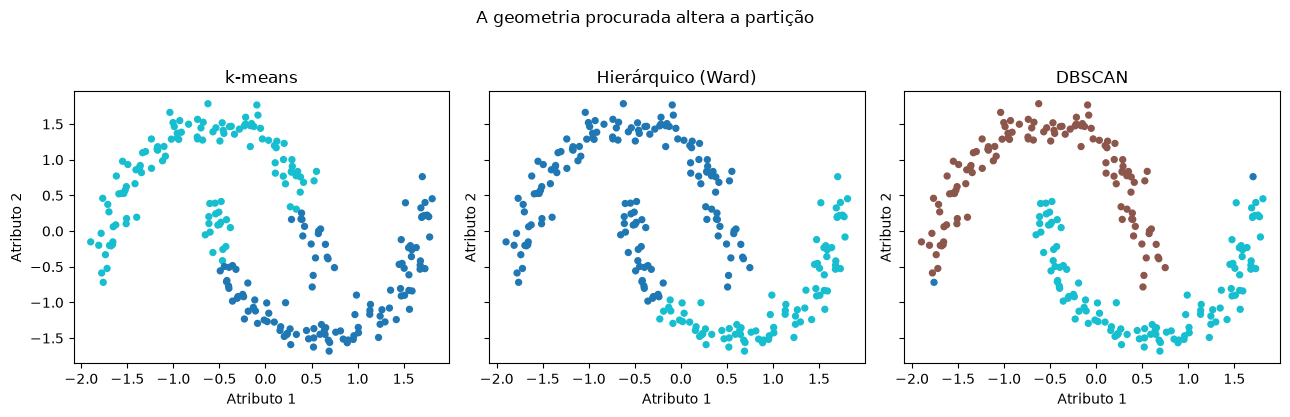

,método,grupos,objetos_ruído
0,k-means,2,0
1,Hierárquico (Ward),2,0
2,DBSCAN,2,2


In [8]:
modelos = {
    "k-means": KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE),
    "Hierárquico (Ward)": AgglomerativeClustering(n_clusters=2, linkage="ward"),
    "DBSCAN": DBSCAN(eps=eps_candidato, min_samples=min_samples),
}
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
resumo = []
for ax, (nome, modelo) in zip(axes, modelos.items()):
    labels = modelo.fit_predict(X_luas)
    n_grupos = len(set(labels) - {-1})
    n_ruido = int(np.sum(labels == -1))
    resumo.append({"método": nome, "grupos": n_grupos, "objetos_ruído": n_ruido})
    ax.scatter(X_luas[:, 0], X_luas[:, 1], c=labels, cmap="tab10", s=18)
    ax.set(title=nome, xlabel="Atributo 1", ylabel="Atributo 2")
fig.suptitle("A geometria procurada altera a partição", y=1.03)
fig.tight_layout()
plt.show()
display(pd.DataFrame(resumo))

## 7. Quando considerar cada abordagem

| Situação | Abordagem a considerar | Ressalva |
|---|---|---|
| partição compacta, grande volume e $k$ conhecido | k-means | sensível à escala, ruído e formas não convexas |
| explorar níveis e visualizar fusões | hierárquico | custo e fusões não revistas |
| formas não convexas e ruído explícito | DBSCAN | parâmetros sensíveis e densidades diferentes |

Documente unidade de análise, atributos, escala, métrica, geometria esperada, tratamento de ruído e uso pretendido.

## 8. Atividades

**U06-NB02-V01.** Um dendrograma de ligação completa apresenta uma fusão na altura 4,2. Explique o que esse número representa e por que ele não significa que o novo grupo possui 4,2 objetos.

**U06-NB02-E01.** Considere $C_1=\{A=(0,0),B=(0,1)\}$ e $C_2=\{C=(4,0),D=(4,2)\}$. Calcule a distância entre os grupos pelas ligações simples, completa e média. Calcule também o aumento da SSE de Ward e explique por que os valores não precisam coincidir.

**U06-NB02-E02.** No dendrograma de Ward deste notebook, o corte na altura 2,0 gera quais grupos? Descreva a leitura visual e confirme-a pela tabela.

**U06-NB02-E03.** No exemplo com `eps=0.55` e `min_samples=5`, classifique P–W como centrais, borda ou ruído. Explique por que aumentar apenas `min_samples` pode mudar essas classificações.

**U06-NB02-E04.** Uma equipe quer segmentar trajetórias geográficas que formam rotas curvas, contêm registros isolados e não possuem número confiável de grupos. Compare k-means, Ward e DBSCAN; indique uma escolha inicial, as decisões a documentar e uma limitação a investigar.

## 9. Síntese

- A hierarquia representa partições em diferentes níveis, condicionadas pela distância e pela ligação.
- A altura do dendrograma registra o critério de fusão; um corte produz uma partição.
- Ligação simples privilegia proximidade local; completa, proximidade global; média é intermediária; Ward reduz o aumento da SSE.
- DBSCAN conecta regiões densas e distingue pontos centrais, de borda e ruído.
- `eps` e `min_samples` definem o que o método considera denso.
- Grupos resultam de escolhas analíticas. O próximo notebook tratará de avaliação e seleção responsável.

## Referências

- HAN, J.; PEI, J.; TONG, H. *Data Mining: Concepts and Techniques*. 4. ed. Morgan Kaufmann, 2023. Seções 8.3 e 8.4.1.
- SCIPY COMMUNITY. `scipy.cluster.hierarchy`. Documentação oficial.
- SCIKIT-LEARN DEVELOPERS. `AgglomerativeClustering` e `DBSCAN`. Documentação oficial.

Os dados e as figuras deste notebook são autorais e gerados localmente.